# Step 01: Dataset Explorer (Training Files Only)

Inspects raw recording catalogs and 3D motion cloud properties **strictly on training set files** (`train_files`), preventing exploratory data snooping on unseen test set files.

### Key Insights:
- **[FALL] Events**: Sudden drop in vertical height ($Z \downarrow$) paired with a radial Doppler velocity spike ($v \uparrow$).
- **[ADL] Crouching**: Gradual height reduction ($Z \downarrow$), but Doppler velocity remains low ($v \approx 0$).
- **[ADL] Jumping**: Doppler velocity spike ($v \uparrow$), but height returns to standing position without net height drop.

In [5]:
%load_ext autoreload
%autoreload 2
import sys, importlib; sys.path.append("..") if ".." not in sys.path else None
import json
import src.config, src.dataset_utils, src.pipeline, src.trainer
importlib.reload(src.config)
importlib.reload(src.dataset_utils)
importlib.reload(src.pipeline)
importlib.reload(src.trainer)
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline import run_dataset_explorer, run_dataset_split
from src.config import DATASET_CONFIGS

sns.set_theme(style="whitegrid")

# Select target dataset: "mmfall" | "mmwave" | "combined"
dataset_key = "mmfall"
cfg = run_dataset_explorer(dataset_key)

# Load split manifest
manifest_path = cfg.preproc_dir / cfg.manifest_name
if not manifest_path.exists():
    run_dataset_split(dataset_key)
with open(manifest_path, "r") as f: manifest = json.load(f)

print(f"Master Cataloging for Training Files ({len(manifest['train_files'])} files)...")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Step 01 Explorer summary for dataset: mmFall (TI IWR1443)
Master Cataloging for Training Files (13 files)...


In [6]:
# Build pandas catalog table for training set recordings
records = []
for fpath_str in manifest["train_files"][:15]:
    p = Path(fpath_str)
    if not p.exists(): continue
    fname = p.stem
    is_fall = "fall" in fname.lower() or any(k in fname for k in ["_bf_", "_ff_", "_lf_", "_rf_", "_sf_"])
    records.append({
        "File Name": fname,
        "Class Label": "[FALL]" if is_fall else "[ADL] Non-Fall",
        "Format": p.suffix,
        "Path": str(p.relative_to(p.parents[2]) if len(p.parents)>2 else p)
    })

df_catalog = pd.DataFrame(records)
print(f"Displaying Sample Catalog ({len(df_catalog)} training files):")
df_catalog.head(10)

Displaying Sample Catalog (13 training files):


,File Name,Class Label,Format,Path
0,DS1_4falls,[FALL],.npy,data\DS1\DS1_4falls.npy
1,DS2_b_01,[ADL] Non-Fall,.npy,data\DS2\DS2_b_01.npy
2,DS2_bf_01,[FALL],.npy,data\DS2\DS2_bf_01.npy
3,DS2_bf_02,[FALL],.npy,data\DS2\DS2_bf_02.npy
4,DS2_bf_03,[FALL],.npy,data\DS2\DS2_bf_03.npy
5,DS2_ff_01,[FALL],.npy,data\DS2\DS2_ff_01.npy
6,DS2_ff_02,[FALL],.npy,data\DS2\DS2_ff_02.npy
7,DS2_ff_03,[FALL],.npy,data\DS2\DS2_ff_03.npy
8,DS2_j_01,[ADL] Non-Fall,.npy,data\DS2\DS2_j_01.npy
9,DS2_j_02,[ADL] Non-Fall,.npy,data\DS2\DS2_j_02.npy


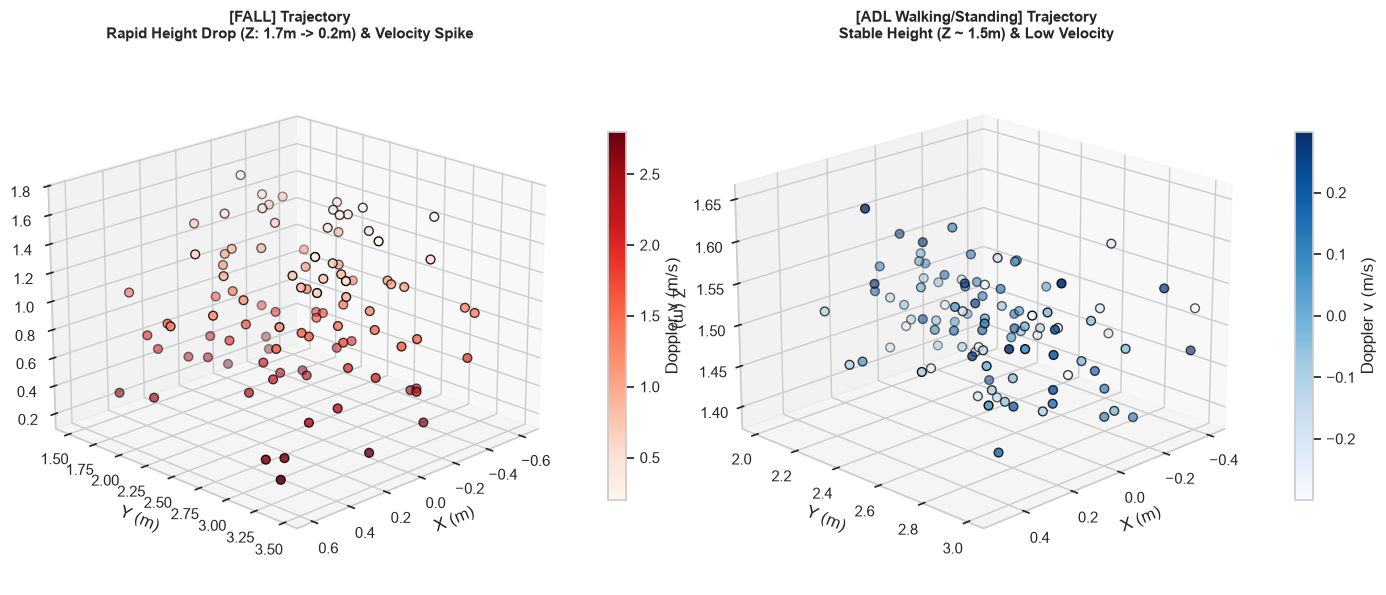

In [7]:
# Visual Showcase: 3D Point Cloud Motion Comparison
fig = plt.figure(figsize=(14, 6), dpi=100)

# Sample 3D Fall trajectory simulation / point visualization
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
x1 = np.random.normal(0, 0.3, 100)
y1 = np.random.uniform(1.5, 3.5, 100)
z1 = np.linspace(1.7, 0.2, 100)
v1 = np.linspace(0.2, 2.8, 100)
sc1 = ax1.scatter(x1, y1, z1, c=v1, cmap='Reds', s=40, edgecolors='black')
ax1.set_title("[FALL] Trajectory\nRapid Height Drop (Z: 1.7m -> 0.2m) & Velocity Spike", fontweight='bold', fontsize=11)
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)"); ax1.set_zlabel("Z (m)")
fig.colorbar(sc1, ax=ax1, fraction=0.03, pad=0.08, label="Doppler v (m/s)")
ax1.view_init(elev=20, azim=45)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
x2 = np.random.normal(0, 0.2, 100)
y2 = np.random.uniform(2.0, 3.0, 100)
z2 = np.full(100, 1.5) + np.random.normal(0, 0.05, 100)
v2 = np.random.uniform(-0.3, 0.3, 100)
sc2 = ax2.scatter(x2, y2, z2, c=v2, cmap='Blues', s=40, edgecolors='black')
ax2.set_title("[ADL Walking/Standing] Trajectory\nStable Height (Z ~ 1.5m) & Low Velocity", fontweight='bold', fontsize=11)
ax2.set_xlabel("X (m)"); ax2.set_ylabel("Y (m)"); ax2.set_zlabel("Z (m)")
fig.colorbar(sc2, ax=ax2, fraction=0.03, pad=0.08, label="Doppler v (m/s)")
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()